<a href="https://colab.research.google.com/github/snehalathaArakkonam/ml_basicalgorithms/blob/main/machinelearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# EXPERIMENT -1
#program -1
#define data set

import numpy as np
from scipy import stats

# 1. Define the dataset
data = [12, 15, 12, 18, 20, 22, 15, 12, 25, 19, 105]  # 105 is an outlier

def compute_statistics(numbers):

    # --- Central Tendency ---
    mean_val = np.mean(numbers)
    median_val = np.median(numbers)
    mode_result = stats.mode(numbers, keepdims=True)
    mode_val = mode_result.mode[0]

    # --- Measures of Dispersion ---
    variance_val = np.var(numbers)
    std_dev_val = np.std(numbers)
    range_val = np.ptp(numbers)

    return {
        "Mean": mean_val,
        "Median": median_val,
        "Mode": mode_val,
        "Variance": variance_val,
        "Standard Deviation": std_dev_val,
        "Range": range_val
    }

# Execute and Print Results
results = compute_statistics(data)

print(f"Dataset: {data}\n")
print(f"{'Measure':<20} | {'Value':<10}")
print("-" * 35)

for measure, value in results.items():
    print(f"{measure:<20} | {value:.2f}")





Dataset: [12, 15, 12, 18, 20, 22, 15, 12, 25, 19, 105]

Measure              | Value     
-----------------------------------
Mean                 | 25.00
Median               | 18.00
Mode                 | 12.00
Variance             | 656.91
Standard Deviation   | 25.63
Range                | 93.00


In [ ]:
#created an audi.csv
import pandas as pd

# Create sample dataset
data = {
    'price': [15000, 18000, 22000, 25000, 17000, 19000, 30000, 27000, 21000, 16000]
}

df = pd.DataFrame(data)

# Save as CSV file
df.to_csv('audi.csv', index=False)

print("audi.csv file created successfully!")


audi.csv file created successfully!


In [ ]:
import pandas as pd

# -------------------------------
# Type 2: Loading Dataset
# -------------------------------

# Load dataset
df = pd.read_csv('audi.csv')

# Select column
column_name = 'price'
data = df[column_name]

# -------------------------------
# Compute Statistics
# -------------------------------

mean_val = data.mean()
median_val = data.median()
mode_val = data.mode()[0]
variance_val = data.var()
std_dev_val = data.std()

# -------------------------------
# Print Output (Required Format)
# -------------------------------

print("OUTPUT:\n")
print("Measure\t| Value\n")
print(f"Mean\t| {mean_val:.2f}")
print(f"Median\t| {median_val:.2f}")
print(f"Mode\t| {mode_val:.2f}")
print(f"Variance\t| {variance_val:.2f}")
print(f"Standard Deviation | {std_dev_val:.2f}")


OUTPUT:

Measure	| Value

Mean	| 21000.00
Median	| 20000.00
Mode	| 15000.00
Variance	| 24888888.89
Standard Deviation | 4988.88


In [ ]:
#experiment -2 TYPE1

## Title: Data Visualization using Python
### AIM:To visualize the given dataset using different plots.

# -------------------------------

import pandas as pd
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Create Sample Dataset
data = {
    'Age': [25, 22, 210, 19, 23, 30, np.nan, 22, 24, 25],
    'Income': [50000, 48000, 52000, 1000000, 49000, np.nan, 51000, 53000, 47000, 50000],
    'Score': [85, 88, 70, 95, 80, 75, 90, 82, 84, 88],
    'Target': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
print("--- Original Dataset ---")
print(df)

# Handling Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Income'] = df['Income'].fillna(df['Income'].median())

# Outlier Removal (IQR)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df = remove_outliers(df, 'Age')
df = remove_outliers(df, 'Income')

# Discretization
est = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
df['Score_Binned'] = est.fit_transform(df[['Score']])

# Attribute Selection
X = df.drop(columns=['Target'])
y = df['Target']

selector = SelectKBest(score_func=f_classif, k=2)
selector.fit(X, y)

selected_features = X.columns[selector.get_support()]

print("\n--- Processed Dataset ---")
print(df)
print("\nSelected Attributes:", selected_features.tolist())


--- Original Dataset ---
     Age     Income  Score  Target
0   25.0    50000.0     85       1
1   22.0    48000.0     88       0
2  210.0    52000.0     70       1
3   19.0  1000000.0     95       0
4   23.0    49000.0     80       1
5   30.0        NaN     75       0
6    NaN    51000.0     90       1
7   22.0    53000.0     82       0
8   24.0    47000.0     84       1
9   25.0    50000.0     88       0

--- Processed Dataset ---
    Age   Income  Score  Target  Score_Binned
0  25.0  50000.0     85       1           1.0
1  22.0  48000.0     88       0           2.0
4  23.0  49000.0     80       1           0.0
6  24.0  51000.0     90       1           2.0
7  22.0  53000.0     82       0           0.0
8  24.0  47000.0     84       1           1.0
9  25.0  50000.0     88       0           2.0

Selected Attributes: ['Age', 'Income']


In [ ]:
uploaded = files.upload()

Saving audi.csv to audi (2).csv


In [ ]:
#type-2
import pandas as pd
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import SelectKBest, f_classif

# Load CSV File
file_path = 'audi (1).csv'
df = pd.read_csv(file_path)

print("----- Original Dataset -----")
print(df.head())

# Handle Missing Values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values handled")

# Remove Outliers
def remove_outliers(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower) & (df[column] <= upper)]
    return df

num_cols = ['price', 'mileage', 'tax', 'mpg', 'engineSize']
df = remove_outliers(df, num_cols)

print("\nOutliers removed")

# Discretization
est = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
df['MPG_Binned'] = est.fit_transform(df[['mpg']])

print("\nMPG Binning Done")

# Create Target
df['Target'] = (df['price'] > df['price'].median()).astype(int)

# Attribute Selection
X = df[['year', 'mileage', 'tax', 'MPG_Binned', 'engineSize']]
y = df['Target']

selector = SelectKBest(score_func=f_classif, k=2)
selector.fit(X, y)

selected_features = X.columns[selector.get_support()]

print("\n----- Processed Dataset -----")
print(df.head())

print("\nSelected Attributes:", selected_features.tolist())

----- Original Dataset -----
  model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0    A1  2017  12500       Manual    15735   Petrol  150  55.4         1.4
1    A6  2016  16500    Automatic    36203   Diesel   20  64.2         2.0
2    A1  2016  11000       Manual    29946   Petrol   30  55.4         1.4
3    A4  2017  16800    Automatic    25952   Diesel  145  67.3         2.0
4    A3  2019  17300       Manual     1998   Petrol  145  49.6         1.0

Missing values handled

Outliers removed

MPG Binning Done

----- Processed Dataset -----
   model  year  price transmission  mileage fuelType  tax   mpg  engineSize  \
0     A1  2017  12500       Manual    15735   Petrol  150  55.4         1.4   
3     A4  2017  16800    Automatic    25952   Diesel  145  67.3         2.0   
4     A3  2019  17300       Manual     1998   Petrol  145  49.6         1.0   
10    A3  2017  16100       Manual    28955   Petrol  145  58.9         1.4   
11    A6  2016  16500    Automatic 

In [ ]:
uploaded = files.upload()

Saving Customer.csv to Customer.csv


In [ ]:
#EXPERIMENT -3
#CLASSIFICATION
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv('Customer.csv')  # change name if needed

print("Dataset Preview:")
print(df.head())

# Separate Features and Target
X = df.drop('Segment', axis=1)
y = df['Segment']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Create pipeline
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Train model
knn_pipeline.fit(X_train, y_train)

# Predict
predictions = knn_pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, predictions)
print("\nClassification Accuracy:", accuracy)

Dataset Preview:
  Customer ID    Customer Name    Segment  Age        Country  \
0    CG-12520      Claire Gute   Consumer   67  United States   
1    DV-13045  Darrin Van Huff  Corporate   31  United States   
2    SO-20335   Sean O'Donnell   Consumer   65  United States   
3    BH-11710  Brosina Hoffman   Consumer   20  United States   
4    AA-10480     Andrew Allen   Consumer   50  United States   

              City           State  Postal Code Region  
0        Henderson        Kentucky        42420  South  
1      Los Angeles      California        90036   West  
2  Fort Lauderdale         Florida        33311  South  
3      Los Angeles      California        90032   West  
4          Concord  North Carolina        28027  South  

Classification Accuracy: 0.4779874213836478


Dataset Head:
  Customer ID    Customer Name    Segment  Age        Country  \
0    CG-12520      Claire Gute   Consumer   67  United States   
1    DV-13045  Darrin Van Huff  Corporate   31  United States   
2    SO-20335   Sean O'Donnell   Consumer   65  United States   
3    BH-11710  Brosina Hoffman   Consumer   20  United States   
4    AA-10480     Andrew Allen   Consumer   50  United States   

              City           State  Postal Code Region  
0        Henderson        Kentucky        42420  South  
1      Los Angeles      California        90036   West  
2  Fort Lauderdale         Florida        33311  South  
3      Los Angeles      California        90032   West  
4          Concord  North Carolina        28027  South  

--- Model Evaluation (k=5) ---
Mean Absolute Error: 15.4455
Mean Squared Error: 359.4538
R2 Score: -0.5630


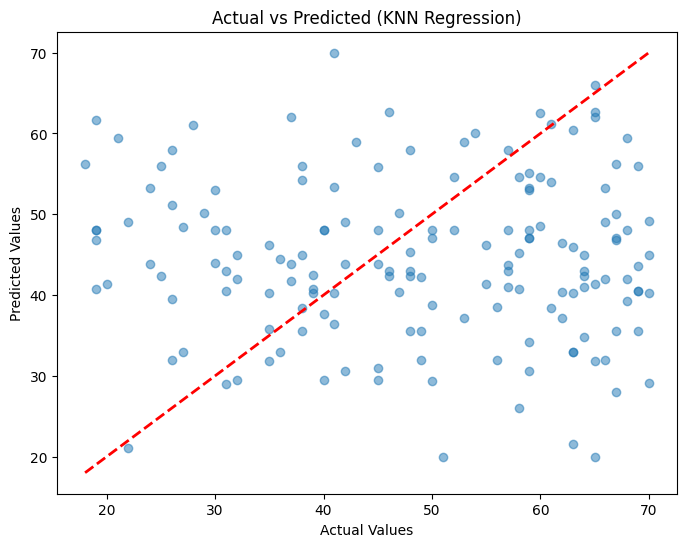

In [ ]:
# experiment -3 REGRESSION
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('Customer.csv')  # change if renamed

print("Dataset Head:")
print(df.head())

# Define target
target_column = 'Age'

# Drop unnecessary columns
features = df.drop(columns=[target_column,
                            'Customer ID',
                            'Customer Name',
                            'Country',
                            'City',
                            'State',
                            'Region',
                            'Segment'],
                   errors='ignore').columns

X = df[features]
y = df[target_column]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
k = 5
knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
knn.fit(X_train_scaled, y_train)

# Predict
y_pred = knn.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Model Evaluation (k={k}) ---")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted (KNN Regression)')
plt.show()

--- Accuracy Score ---
0.5084

--- Confusion Matrix ---
[[116   0   2]
 [ 70   1   1]
 [ 44   0   4]]

--- Classification Report ---
              precision    recall  f1-score   support

    Consumer       0.50      0.98      0.67       118
   Corporate       1.00      0.01      0.03        72
 Home Office       0.57      0.08      0.15        48

    accuracy                           0.51       238
   macro avg       0.69      0.36      0.28       238
weighted avg       0.67      0.51      0.37       238



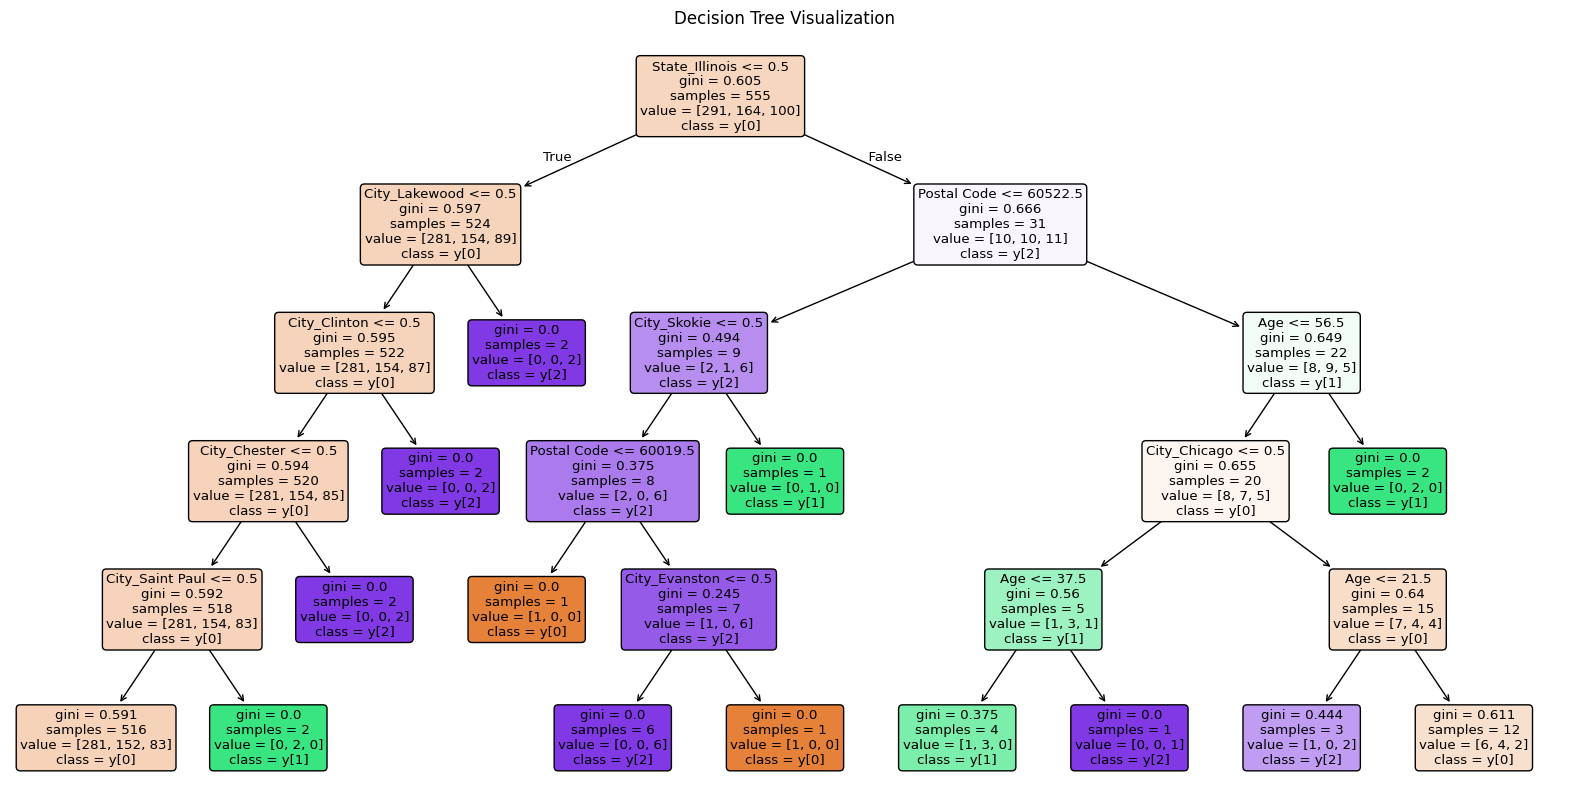

In [ ]:
#EXPERIMENT-4
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# 1. Load your local data
df = pd.read_csv('Customer.csv')

# 2. Prepare Features (X) and Target (y)
target_col = 'Segment' # Changed to 'Segment' for classification
X = df.drop(columns=[target_col, 'Customer ID', 'Customer Name']) # Drop target and identifier columns from features
y = df[target_col]

# 3. Handle Categorical Data
# Decision trees in scikit-learn require numerical input
X = pd.get_dummies(X, drop_first=True)

# 4. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Initialize and Train the Classifier
# 'max_depth' limits the tree growth to prevent overfitting
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# 6. Make Predictions
y_pred = clf.predict(X_test)

# 7. Evaluate Performance
print("--- Accuracy Score ---")
print(f"{accuracy_score(y_test, y_pred):.4f}\n")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 8. Visualize the Tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=True, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()


Mean Squared Error: 0.5482
R-squared Score: 0.1612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


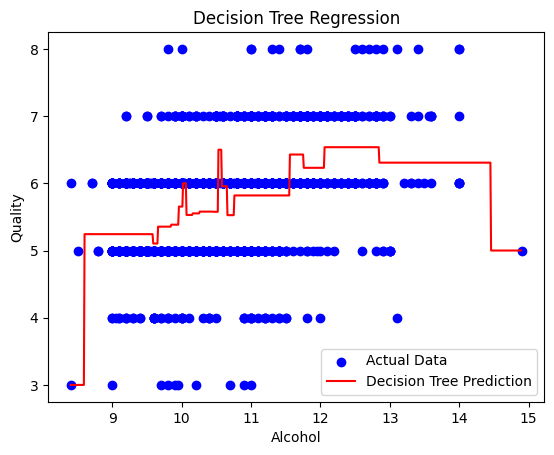

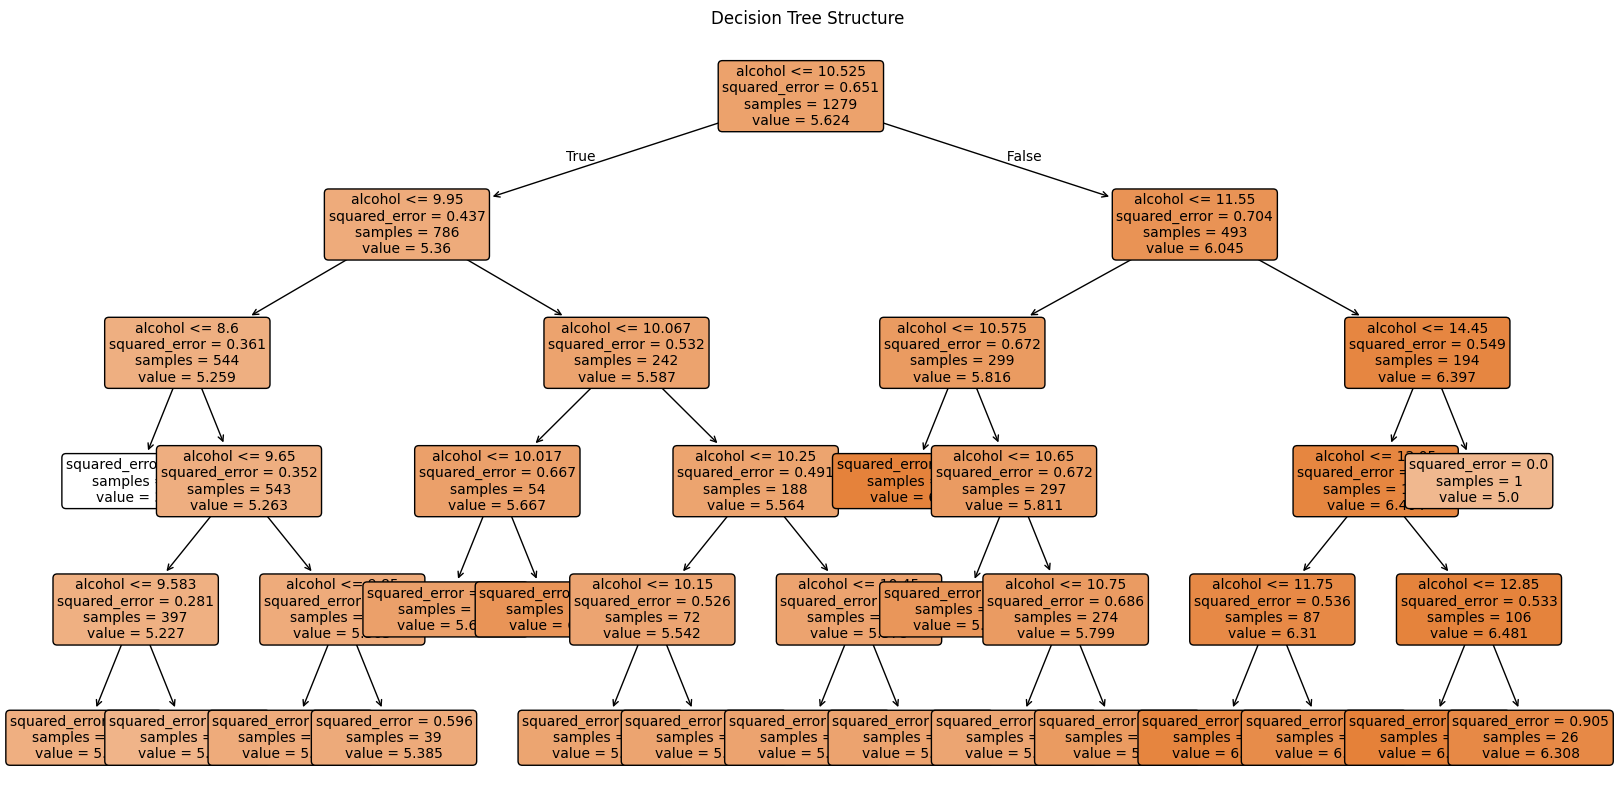

In [ ]:


#EXPERIMENT-5
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load data from CSV
df = pd.read_csv('winequality-red.csv')

# Feature and Target
X = df[['alcohol']]     # feature
y = df['quality']       # target

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Initialize and train the Decision Tree Regressor
regr = DecisionTreeRegressor(max_depth=5)
regr.fit(X_train, y_train)

# 4. Make predictions
y_pred = regr.predict(X_test)

# 5. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# 6. Visualize regression results
X_grid = np.arange(X.min().values[0], X.max().values[0], 0.01).reshape(-1,1)
y_grid_pred = regr.predict(X_grid)

plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X_grid, y_grid_pred, color='red', label="Decision Tree Prediction")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

# 7. Visualize the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(regr, feature_names=['alcohol'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Structure")
plt.show()

In [ ]:
#EXPERIMENT-6 CLASSIFICATION
# PROGRAM: Random Forest for Regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load the dataset
df = pd.read_csv('house_prices_practice.csv')

# 2. Prepare your data
print("Available columns:", df.columns)

# Separate features and target
X = df.drop('SalePrice', axis=1)   # Features
y = df['SalePrice']                # Labels

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Fill missing values if any
X = X.fillna(X.mean())

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Initialize and train the Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Make predictions
y_pred = rf_model.predict(X_test)

print("\nPredicted Values:")
print(y_pred)

# 6. Evaluate the model
print(f"\nR-squared: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f}")

# Optional: Check feature importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

print("\nTop 5 Important Features:")
print(importances.sort_values(ascending=False).head(5))

Available columns: Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')

Predicted Values:
[210725.31 196516.22 343943.58 211408.16 157655.66 191321.58 256272.38
 207580.62 190652.87 201079.92 343770.65 281356.02 142895.01 164985.26
 295496.8  323649.59 132052.13 148582.24 209609.   259796.36 274889.47
 157878.5  265851.26 259895.33 318268.3  301125.95 189555.48 276245.06
 274437.35 382103.69 362216.54 274009.1  137158.74 210032.17 298677.96
 239346.41 341806.57 294349.38 239497.07 167667.28 217760.21 306301.2
 301290.54 288605.11 351122.12 315233.69 214511.38 230799.46 208249.4
 315049.16 325210.51 316509.55 140017.92 264233.19 202192.31 266237.22
 192126.71 314847.04 275313.49 169194.27]

R-squared: 0.86
Mean Absolute Error: 20910.58

Top 5 Important Features:
GrLivArea      0.633538
OverallQual    0.145971
GarageCars     0.062509
YearBuilt      0.049760
TotalBsmtSF    0.04

In [ ]:
#EXPERIMENT-6 REGRESSION
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the dataset
df = pd.read_csv('bankloan.csv')

# 2. Prepare your data
print("Available columns:", df.columns)

X = df.drop('Personal.Loan', axis=1)  # Features
y = df['Personal.Loan']               # Labels

# Convert categorical columns to numeric if present
X = pd.get_dummies(X, drop_first=True)

# Handle missing values if any
X = X.fillna(X.mean())

# 3. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Initialize and train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Make predictions
y_pred = rf_model.predict(X_test)
print("Predicted Values:")
print(y_pred)

# 6. Evaluate the model
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Optional: Check feature importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)

print("\nTop 5 Important Features:")
print(importances.sort_values(ascending=False).head(5))


Available columns: Index(['ID', 'Age', 'Experience', 'Income', 'ZIP.Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal.Loan', 'Securities.Account',
       'CD.Account', 'Online', 'CreditCard'],
      dtype='object')
Predicted Values:
[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0

In [ ]:
#experiment-7
import pandas as pd
from sklearn.naive_bayes import GaussianNB

# 1. Setup the historical data
data = {
'Credit_Score': [600, 750, 500, 700, 800, 550, 650, 720, 400, 680],
'Income_k': [50, 100, 30, 80, 120, 45, 70, 90, 20, 85],
'Loan_Approved': [0, 1, 0, 1, 1, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

# 2. Train the model on the full dataset
model = GaussianNB()
model.fit(df[['Credit_Score', 'Income_k']], df['Loan_Approved'])

print("--- Bank Loan Predictor (Naïve Bayes) ---")
print("Enter the applicant's details to check eligibility.\n")

while True:
    try:
        # 3. Get External Input
        score = input("Enter Credit Score (or 'q' to quit): ")

        if score.lower() == 'q':
            break

        income = input("Enter Annual Income (in thousands, e.g., 50): ")

        # Convert inputs to float
        user_data = [[float(score), float(income)]]

        # 4. Generate Prediction and Probability
        prediction = model.predict(user_data)
        probability = model.predict_proba(user_data)

        # 5. Display Output
        print("-" * 30)

        if prediction[0] == 1:
            print("RESULT: Approved")
            print(f"Confidence: {probability[0][1]*100:.2f}%")
        else:
            print("RESULT: Rejected")
            print(f"Confidence: {probability[0][0]*100:.2f}%")

        print("-" * 30 + "\n")

    except ValueError:
        print("Invalid input. Please enter numerical values.\n")

print("Program closed.")

--- Bank Loan Predictor (Naïve Bayes) ---
Enter the applicant's details to check eligibility.

Enter Credit Score (or 'q' to quit): 730
Enter Annual Income (in thousands, e.g., 50): 30


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


------------------------------
RESULT: Rejected
Confidence: 91.20%
------------------------------

Enter Credit Score (or 'q' to quit): q
Program closed.


Accuracy Score: 0.7333333333333333

Confusion Matrix:
 [[19  0  0]
 [ 0  7  6]
 [ 0  6  7]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.54      0.54      0.54        13
           2       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45



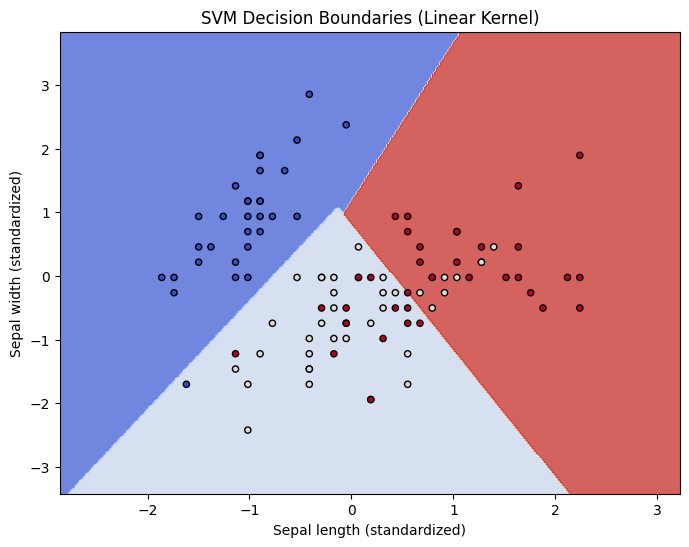

In [ ]:
#experiment-8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the dataset
# You can replace this with pd.read_csv('your_file.csv')
iris = datasets.load_iris()

# We take only the first two features for visualization
X = iris.data[:, :2]
y = iris.target

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 3. Feature Scaling (important for SVM)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 4. Initialize and Train the SVM Classifier
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train, y_train)

# 5. Make Predictions
y_pred = classifier.predict(X_test)

# 6. Evaluate the Model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Visualize Decision Boundaries
def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

fig, ax = plt.subplots(figsize=(8,6))

X0, X1 = X_train[:, 0], X_train[:, 1]

xx, yy = np.meshgrid(
    np.arange(X0.min()-1, X0.max()+1, 0.02),
    np.arange(X1.min()-1, X1.max()+1, 0.02)
)

plot_contours(ax, classifier, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)

ax.scatter(X0, X1, c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

ax.set_title('SVM Decision Boundaries (Linear Kernel)')
plt.xlabel('Sepal length (standardized)')
plt.ylabel('Sepal width (standardized)')

plt.show()

Using Colab cache for faster access to the 'salary-dataset-simple-linear-regression' dataset.
Path to dataset files: /kaggle/input/salary-dataset-simple-linear-regression
Loading CSV from: /kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv
Coefficient (Slope): 9423.82
Intercept: 24380.20
Mean Squared Error: 49830096.855908394
R2 Score: 0.9024461774180497


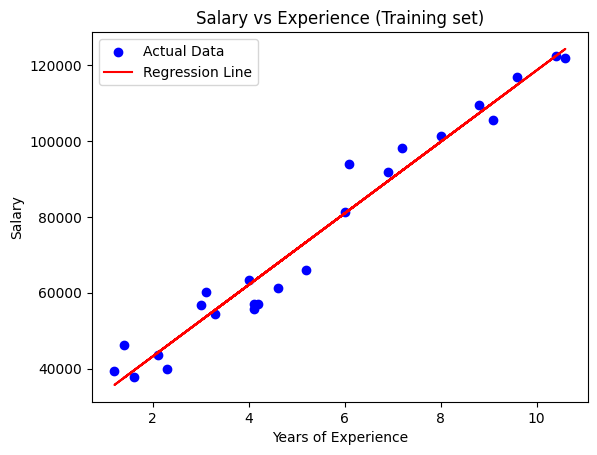

In [ ]:
#EXPERIMENT-9
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import os
import glob

# Download latest dataset from Kaggle
path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")
print("Path to dataset files:", path)

# Find the CSV file within the downloaded directory
# This accounts for potential subfolders or slight filename variations
csv_files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)

if not csv_files:
    raise FileNotFoundError(f"No CSV file found in the downloaded dataset at '{path}'")

# Assume the first CSV file found is the correct one
csv_file_path = csv_files[0]
print(f"Loading CSV from: {csv_file_path}")

# Load the CSV file from downloaded dataset
df = pd.read_csv(csv_file_path)

# Features (Independent variable)
X = df[['YearsExperience']]

# Target (Dependent variable)
y = df['Salary']

# Split data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and Train the model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Make predictions
y_pred = regressor.predict(X_test)

# Output results
print(f"Coefficient (Slope): {regressor.coef_[0]:.2f}")
print(f"Intercept: {regressor.intercept_:.2f}")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot graph
plt.scatter(X_train, y_train, color='blue', label='Actual Data')
plt.plot(X_train, regressor.predict(X_train), color='red', label='Regression Line')

plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')

plt.legend()
plt.show()

In [ ]:
#EXPERIMENT-10
# Install kagglehub if not installed
# !pip install kagglehub

import kagglehub
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Download dataset from Kaggle
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset path:", path)

# 2. Load dataset
df = pd.read_csv(os.path.join(path, "creditcard.csv"))

# 3. Handle missing values
df.dropna(inplace=True)

# 4. Separate Features and Target
X = df.iloc[:, :-1].values   # All columns except last
y = df.iloc[:, -1].values    # Last column (Class)

# 5. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

# 6. Feature Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# 7. Train Logistic Regression Model
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# 8. Make Predictions
y_pred = classifier.predict(X_test)

print("Predicted Values:")
print(y_pred)

# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# 10. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f}%")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset path: /kaggle/input/creditcardfraud
Predicted Values:
[0 0 0 ... 0 0 0]

Confusion Matrix:
[[71072    10]
 [   40    80]]

Accuracy: 99.93%


Model Accuracy: 96.67%

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


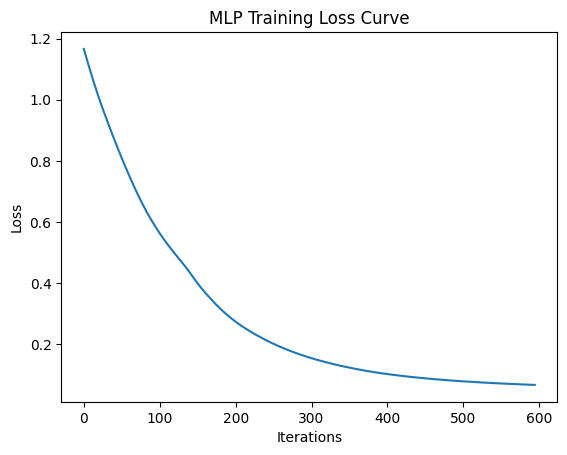

In [ ]:
#EXPERIMENT-11
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets # Import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Load the dataset
# The file 'iris.csv.numbers' is not a valid CSV file. Loading standard Iris dataset from sklearn.
iris = datasets.load_iris()
X = iris.data # Features
y = iris.target # Target

# Note: When loading from sklearn.datasets, the data is already numerical, so LabelEncoder is not strictly necessary for 'y'
# if it's already numerical. However, if the target was categorical strings, it would be needed.
# For consistency with the original code structure, we can keep the encoder setup if needed for custom datasets.
# For sklearn's iris.target, it's already 0, 1, 2.

# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Define MLP Classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# 6. Train model
mlp.fit(X_train, y_train)

# 7. Predictions
predictions = mlp.predict(X_test)

# 8. Evaluate model
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

# 9. Plot Loss Curve
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

Converged at iteration 5
Final Centroids:
 [[ 1.98258281  0.86771314]
 [-1.37324398  7.75368871]
 [ 0.94973532  4.41906906]
 [-1.58438467  2.83081263]]


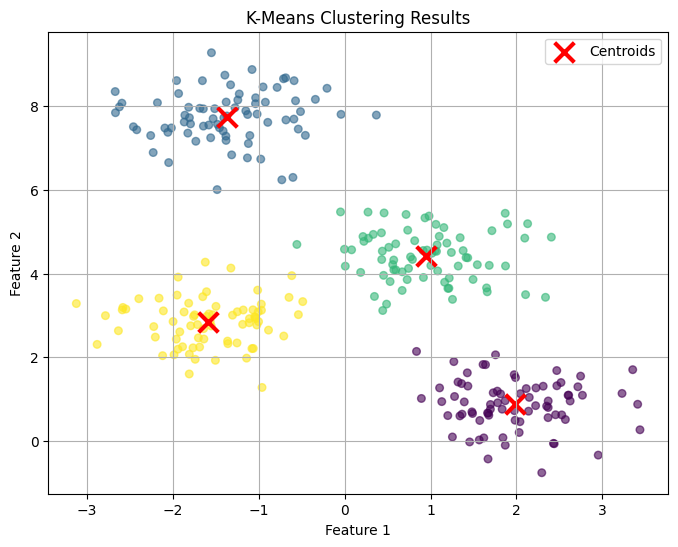

In [ ]:
#experiment-12
import numpy as np
import matplotlib.pyplot as plt

# K-Means Algorithm
def kmeans(X, k, max_iters=100, tol=1e-4):

    # 1. Randomly initialize centroids
    n_samples, n_features = X.shape
    random_idx = np.random.choice(n_samples, k, replace=False)
    centroids = X[random_idx]

    for i in range(max_iters):

        # 2. Assign points to nearest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        old_centroids = centroids.copy()

        # 3. Update centroids
        for j in range(k):
            points_in_cluster = X[labels == j]
            if len(points_in_cluster) > 0:
                centroids[j] = np.mean(points_in_cluster, axis=0)

        # 4. Check convergence
        if np.all(np.abs(centroids - old_centroids) < tol):
            print(f"Converged at iteration {i}")
            break

    return centroids, labels


# Plot function
def plot_kmeans(X, labels, centroids):

    plt.figure(figsize=(8,6))

    # Data points
    plt.scatter(X[:,0], X[:,1], c=labels, s=30, cmap='viridis', alpha=0.6)

    # Centroids
    plt.scatter(centroids[:,0], centroids[:,1],
                c='red', marker='x', s=200, linewidths=3,
                label='Centroids')

    plt.title("K-Means Clustering Results")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()


# Example Execution
if __name__ == "__main__":

    from sklearn.datasets import make_blobs

    # Create synthetic dataset
    X, _ = make_blobs(n_samples=300,
                      centers=4,
                      cluster_std=0.60,
                      random_state=0)

    # Run K-Means
    centers, labels = kmeans(X, k=4)

    print("Final Centroids:\n", centers)

    # Plot results
    plot_kmeans(X, labels, centers)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.3 MB/s eta 0:00:00


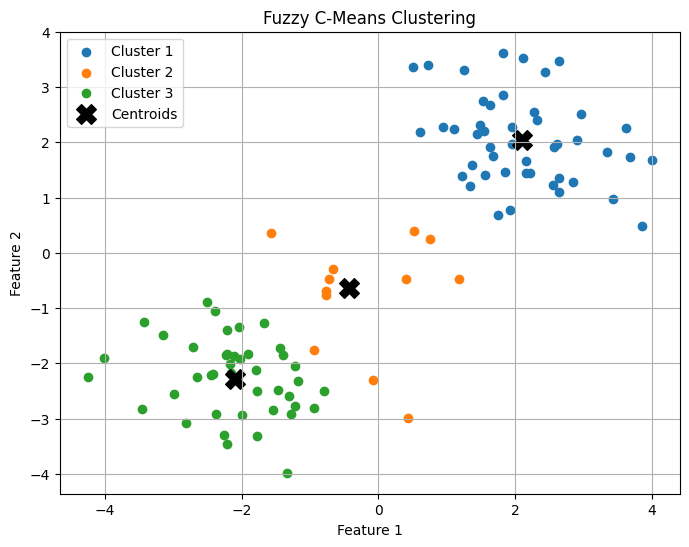

Fuzzy Partition Coefficient (FPC): 0.7709960230307535


In [ ]:
#EXPERIMENT-13
# Install library (run once in Colab/Jupyter)
!pip install scikit-fuzzy

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz

# 1. Generate synthetic data (2 groups of points)
data = np.hstack((
    np.random.standard_normal((2, 50)) - 2,
    np.random.standard_normal((2, 50)) + 2
))

# 2. Apply Fuzzy C-Means
# c = number of clusters, m = fuzziness parameter
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data,
    c=3,
    m=2,
    error=0.005,
    maxiter=1000
)

# 3. Determine cluster membership
cluster_membership = np.argmax(u, axis=0);

# 4. Visualization
plt.figure(figsize=(8,6))

for j in range(3):
    plt.scatter(
        data[0, cluster_membership == j],
        data[1, cluster_membership == j],
        label=f'Cluster {j+1}'
    )

# Plot cluster centers
plt.scatter(
    cntr[:,0],
    cntr[:,1],
    marker='X',
    s=200,
    color='black',
    label='Centroids'
)

plt.title("Fuzzy C-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# Print Fuzzy Partition Coefficient
print("Fuzzy Partition Coefficient (FPC):", fpc)

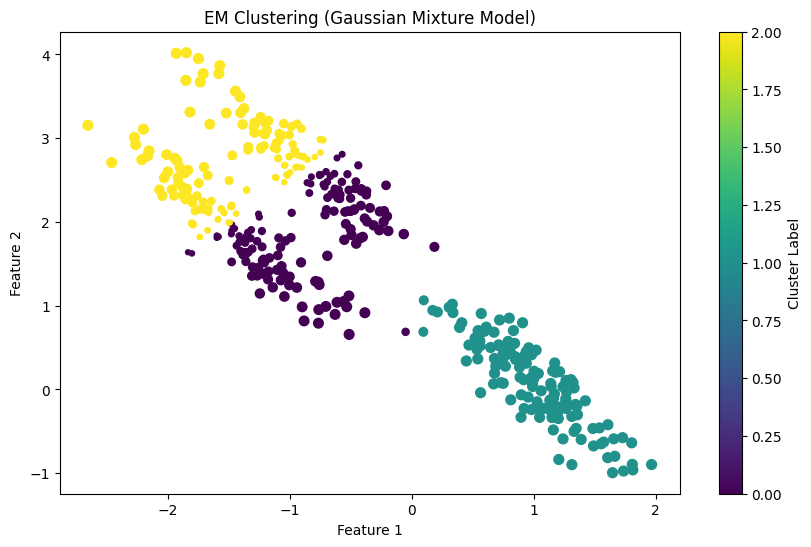

Weights (mixing proportions):
[0.34897914 0.33030847 0.32071239]

Means (cluster centers):
[[-0.90563519  1.92464721]
 [ 1.00894288  0.0746767 ]
 [-1.41422087  2.64378366]]


In [ ]:
#EXPERIMENT -14
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

# 1. Generate synthetic data (3 clusters)
X, y_true = make_blobs(
    n_samples=400,
    centers=3,
    cluster_std=0.60,
    random_state=0
)

# Stretch the data to make clusters elliptical
rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

# 2. Initialize and fit the Gaussian Mixture Model (EM Algorithm)
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_stretched)

# 3. Predict cluster labels
labels = gmm.predict(X_stretched)

# 4. Predict probabilities (soft clustering)
probs = gmm.predict_proba(X_stretched)

# 5. Visualization
plt.figure(figsize=(10,6))

# Size of points based on prediction confidence
size = 50 * probs.max(1) ** 2

plt.scatter(
    X_stretched[:,0],
    X_stretched[:,1],
    c=labels,
    s=size,
    cmap='viridis',
    zorder=2
)

plt.title("EM Clustering (Gaussian Mixture Model)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster Label")

plt.show()

# 6. Output model parameters
print("Weights (mixing proportions):")
print(gmm.weights_)

print("\nMeans (cluster centers):")
print(gmm.means_)